3A. Memahami dataset dan target klasifikasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Memuat dataset
df = pd.read_csv('/content/train.csv')

# Menampilkan informasi dasar dataset
print("--- Info Dataset ---")
print(df.info())
print("\n--- 5 Data Teratas ---")
print(df.head())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- 5 Data Teratas ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5

3B. Preprocessing data yang diperlukan


In [ ]:
df = pd.read_csv('/content/train.csv')

# 2. Mengisi data kosong (Imputation)
# Umur diisi median, Fare diisi median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# 3. Encoding kolom Sex (String -> Angka)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 4. CEK & BERSIHKAN NaN terakhir
# Jika ada baris yang masih kosong setelah proses di atas, kita hapus barisnya
df_clean = df.dropna(subset=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived'])

# 5. Menentukan Fitur (X) dan Target (y) [cite: 7]
X = df_clean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df_clean['Survived']

# 6. Scaling (Penyeragaman Skala)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Jumlah NaN di X setelah perbaikan:", np.isnan(X_scaled).sum())
print("Preprocessing selesai tanpa error!")

Jumlah NaN di X setelah perbaikan: 0
Preprocessing selesai tanpa error!


3C.Pembagian data training dan testing

3D. Membangun model Logistic Regression


In [ ]:
# --- LANGKAH 3C: PEMBAGIAN DATA ---
# Membagi data menjadi 80% untuk latihan (training) dan 20% untuk pengujian (testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data berhasil dibagi:")
print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")


# --- LANGKAH 3D: MEMBANGUN MODEL LOGISTIC REGRESSION ---
from sklearn.linear_model import LogisticRegression

# 1. Inisialisasi model
model = LogisticRegression()

# 2. Melatih model menggunakan data training
model.fit(X_train, y_train)

print("\nModel Logistic Regression berhasil dibangun dan dilatih!")

Data berhasil dibagi:
Jumlah data training: 712
Jumlah data testing: 179

Model Logistic Regression berhasil dibangun dan dilatih!


4A. Classification

4B. Confusion Matrix beserta visualisasinya

HASIL EVALUASI MODEL
------------------------------
               precision    recall  f1-score   support

Meninggal (0)       0.81      0.86      0.83       105
  Selamat (1)       0.78      0.72      0.75        74

     accuracy                           0.80       179
    macro avg       0.80      0.79      0.79       179
 weighted avg       0.80      0.80      0.80       179



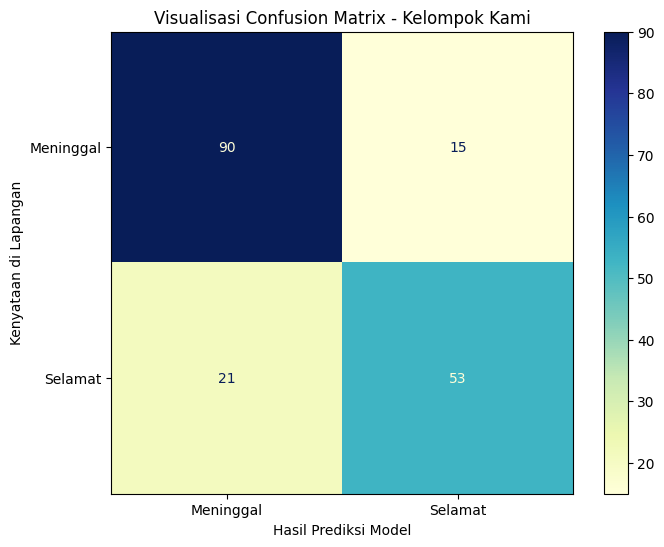

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Bikin prediksi
y_pred = model.predict(X_test)

# 2. Munculin Classification Report
print("HASIL EVALUASI MODEL")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Meninggal (0)', 'Selamat (1)']))

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))

# label sumbu
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Meninggal', 'Selamat'])
disp.plot(ax=ax, cmap='YlGnBu', values_format='d')

plt.title('Visualisasi Confusion Matrix - Kelompok Kami')
plt.xlabel('Hasil Prediksi Model')  # Sumbu X
plt.ylabel('Kenyataan di Lapangan') # Sumbu Y
plt.show()

5. contoh hasil prediksi(y_pred) dan pembandingan dengan label sebenarnya(y_test).

In [ ]:
cek_hasil = pd.DataFrame({
    'Data Asli (y_test)': y_test,
    'Tebakan Model (y_pred)': y_pred
})

# Tampilkan 10 baris aja buat contoh
print("Contoh Perbandingan:")
print(cek_hasil.head(10))

Contoh Perbandingan:
     Data Asli (y_test)  Tebakan Model (y_pred)
709                   1                       0
439                   0                       0
840                   0                       0
720                   1                       1
39                    1                       1
290                   1                       1
300                   1                       1
333                   0                       0
208                   1                       1
136                   1                       1


# Analisis:
# 1. kinerja model berdasarkan Classfication Report:
dari hasil classfication report, model kita dapet skor akurasi sekitar 0.80 atau 80%.
Untuk kategori Meninggal (0), model memiliki precision 0.81 dan recall 0.86, yang artinya model sangat baik dalam mengenali penumpang yang tidak selamat.
Untuk kategori Selamat (1), nilai f1-score berada di angka 0.75. Ini menunjukkan bahwa model sudah cukup optimal, meskipun masih sedikit lebih akurat dalam memprediksi kelas 'Meninggal' dibandingkan kelas 'Selamat'.

# 2.Makna TP, FP, TN, dan FN pada Kasus Titanic Berdasarkan Confusion Matrix yang dihasilkan:


*   True Positive (53):
Penumpang yang aslinya Selamat, dan model berhasil menebaknya dengan benar sebagai Selamat.
*   True Negative (90):
Penumpang yang aslinya Meninggal, dan model berhasil menebaknya dengan benar sebagai Meninggal.


*   False Positive (15):
Penumpang yang aslinya Meninggal, tapi model salah menebaknya sebagai Selamat.

*   False Negative (21):
 Penumpang yang aslinya Selamat, tapi model salah menebaknya sebagai Meninggal.

# 3. Kesimpulan Penggunaan Logistic Regression
Secara keseluruhan, Logistic Regression bekerja dengan sangat baik pada dataset Titanic ini. Dengan akurasi 80%, algoritma ini mampu menangkap pola linear dari fitur-fitur seperti jenis kelamin, kelas tiket, dan umur penumpang untuk memprediksi peluang keselamatan. Hasil ini membuktikan bahwa Logistic Regression adalah pilihan yang tepat dan efisien untuk kasus klasifikasi biner pada dataset ini sebelum mencoba model yang lebih kompleks.
